In [1]:
import cv2
import os
from tqdm import tqdm
import sys

sys.path.append('/projects/OLIVINE/ebianchi/juniorstav/camera_system_analysis')
from object_tracking import (
    template_matching,
    detect_centroids_using_moments,
    combine_bidirectional_matches_with_vertical_priority,
    get_metadata,
    visualize_tracking_three_frames_side_by_side,
    filter_metadata_with_iqr
)

def process_and_validate_tracking(directory, stride=1, output_directory="output"):
    """
    Processes three consecutive images from a directory with a given stride and validates tracking results.

    Args:
        directory (str): Path to the directory containing images.
        stride (int): Stride to move through the images in the directory.
        output_directory (str): Directory to save the visualization of tracking results.

    Returns:
        None
    """
    # Create the output directory if it doesn't exist
    os.makedirs(output_directory, exist_ok=True)

    # Get all image file paths from the directory
    image_files = sorted([os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(('.png', '.jpg', '.jpeg'))])

    # Ensure there are enough images to process
    if len(image_files) < 3:
        print("Not enough images in the directory to process.")
        return
    
    matches = []

    # Iterate through the images with the given stride
    for i in tqdm(range(3, len(image_files) - 2)):
        # Load three consecutive images
        f1, f2, f3 = image_files[i], image_files[i + 1], image_files[i + 2]
        image1 = cv2.imread(f1, cv2.IMREAD_GRAYSCALE)
        image2 = cv2.imread(f2, cv2.IMREAD_GRAYSCALE)
        image3 = cv2.imread(f3, cv2.IMREAD_GRAYSCALE)

        try:
            # Perform template matching and detect centroids
            top_third_template1, matched_region1, max_loc1, offset1 = template_matching(image1, image2)
            top_third_template2, matched_region2, max_loc2, offset2 = template_matching(image2, image3)
            print(offset1)

            centroids_f1_2, color1 = detect_centroids_using_moments(top_third_template1, color=(255, 0, 0), threshold=80, visualize_binary=False)
            centroids_f2_1, color2 = detect_centroids_using_moments(matched_region1, color=(0, 255, 0), threshold=80, visualize_binary=False)
            centroids_f2_3, color3 = detect_centroids_using_moments(top_third_template2, color=(0, 255, 0), threshold=80, visualize_binary=False)
            centroids_f3_2, color3 = detect_centroids_using_moments(matched_region2, color=(0, 255, 0), threshold=80, visualize_binary=False)

            # Combine bidirectional matches with vertical priority
            matches_1_2 = combine_bidirectional_matches_with_vertical_priority(centroids_f1_2, centroids_f2_1)
            match_metadata_1_2 = get_metadata(matches_1_2, offset1)

            matches_2_3 = combine_bidirectional_matches_with_vertical_priority(centroids_f2_3, centroids_f3_2)
            match_metadata_2_3 = get_metadata(matches_2_3, offset2)

            # Generate a unique output filename based on the indices of the images
            output_filename = f"tracking_visualization_{i}_{i+1}_{i+2}.png"
            output_path = os.path.join(output_directory, output_filename)

            filtered_metadata_1_2 = filter_metadata_with_iqr(match_metadata_1_2)
            filtered_metadata_2_3 = filter_metadata_with_iqr(match_metadata_2_3)

            # Visualize tracking across three frames
            # visualize_tracking_three_frames_side_by_side(
            #     image1, image2, image3, filtered_metadata_1_2, filtered_metadata_2_3, output_path=output_path
            # )
            print(len(matches))
            matches = matches + [match for match in match_metadata_2_3]
            matches = matches + [match for match in match_metadata_1_2]

            print(f"Visualization saved to: {output_path}")
        except:
            print(f"failed: {output_path}")
    return matches

# Example usage
directory_path = "/projects/OLIVINE/data/sample_optical_flow/olivine_60_144fps/"
output_directory_path = "/projects/OLIVINE/data/sample_optical_flow/output_olivine_60_144fps/"
matches = process_and_validate_tracking(directory_path, stride=1, output_directory=output_directory_path)


  3%|▎         | 1/36 [00:00<00:10,  3.26it/s]

604
0
Visualization saved to: /projects/OLIVINE/data/sample_optical_flow/output_olivine_60_144fps/tracking_visualization_3_4_5.png


  6%|▌         | 2/36 [00:00<00:10,  3.28it/s]

584
52
Visualization saved to: /projects/OLIVINE/data/sample_optical_flow/output_olivine_60_144fps/tracking_visualization_4_5_6.png


  8%|▊         | 3/36 [00:00<00:09,  3.32it/s]

...

562
2151
Visualization saved to: /projects/OLIVINE/data/sample_optical_flow/output_olivine_60_144fps/tracking_visualization_36_37_38.png


 97%|█████████▋| 35/36 [00:10<00:00,  3.21it/s]

612
2228
Visualization saved to: /projects/OLIVINE/data/sample_optical_flow/output_olivine_60_144fps/tracking_visualization_37_38_39.png


100%|██████████| 36/36 [00:10<00:00,  3.30it/s]

583
2294
Visualization saved to: /projects/OLIVINE/data/sample_optical_flow/output_olivine_60_144fps/tracking_visualization_38_39_40.png


In [2]:
len(matches)

2349

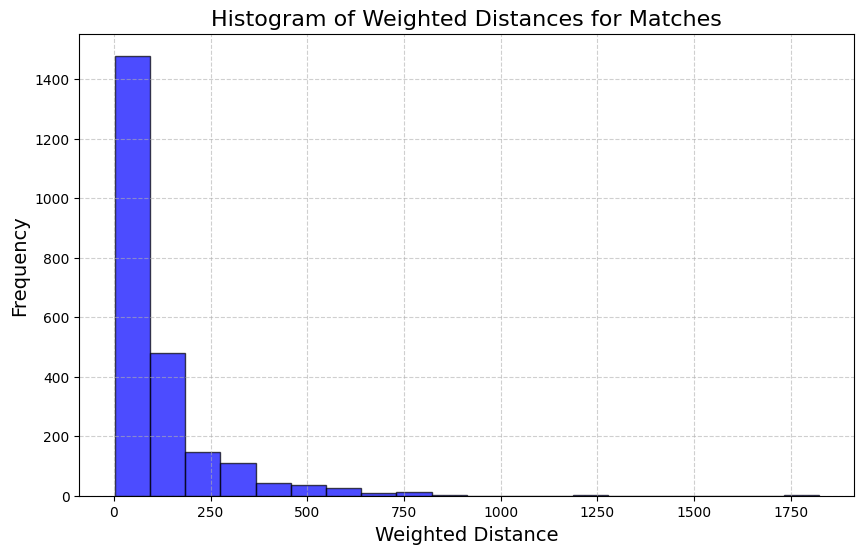

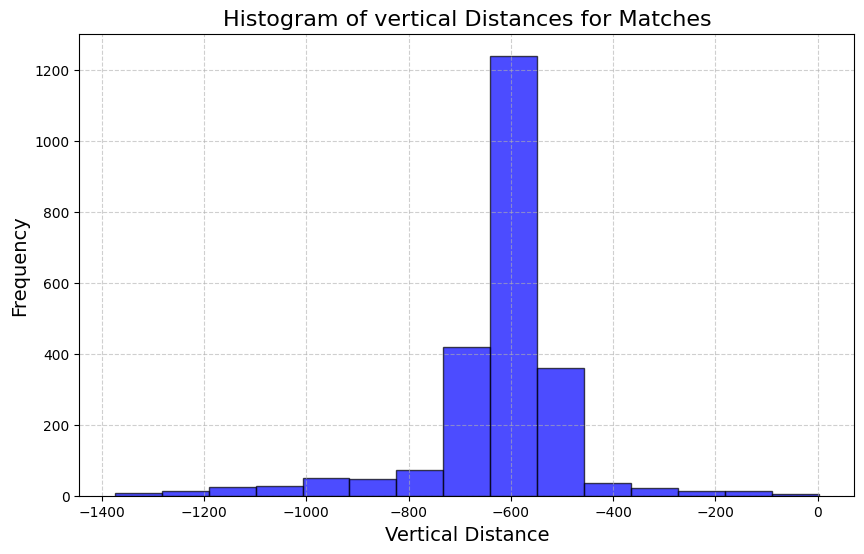

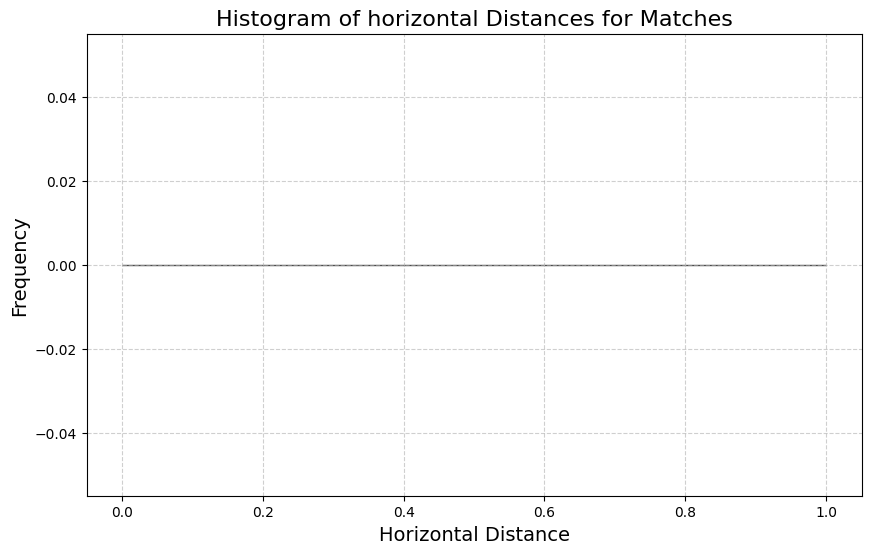

In [3]:
from object_tracking import analyze_and_plot_weighted_distances

analyze_and_plot_weighted_distances(matches)

Variance in 'area_diff': 3622757.8700344376
Variance in 'vol_diff': 11383815.61444084
Variance in 'fmin_dff': 382.6034826131473
Sum in 'area_diff': 111.64331826985152
Sum in 'vol_diff': 160.68943607966995
Sum in 'fmin_dff': 1.7729429906797936
Min in 'area_diff': -10824.5
Min in 'vol_diff': -22810.055914214186
Min in 'fmin_dff': -106.31831422716112


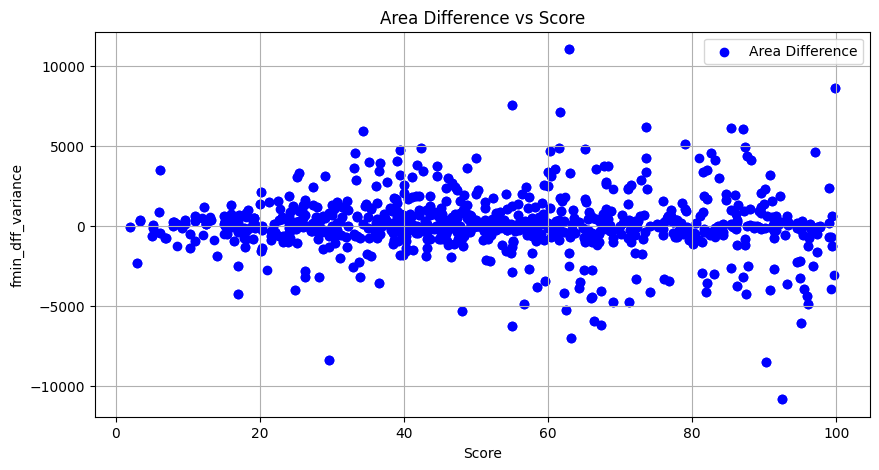

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Filter entries with 'score' < 100
filtered_data = [entry for entry in matches if entry['score'] < 100]

# Step 2: Extract values for variance computation
area_diff_values = [entry['area_diff'] for entry in filtered_data]
vol_diff_values = [entry['vol_diff'] for entry in filtered_data]
fmin_dff_values = [entry['fmin_dff'] for entry in filtered_data]

# Compute variance
area_diff_variance = np.var(area_diff_values)
vol_diff_variance = np.var(vol_diff_values)
fmin_dff_variance = np.var(fmin_dff_values)

print("Variance in 'area_diff':", area_diff_variance)
print("Variance in 'vol_diff':", vol_diff_variance)
print("Variance in 'fmin_dff':", fmin_dff_variance)

# Compute Sum
area_diff_av = np.average(area_diff_values)
vol_diff_av = np.average(vol_diff_values)
fmin_dff_av = np.average(fmin_dff_values)

print("Sum in 'area_diff':", area_diff_av)
print("Sum in 'vol_diff':", vol_diff_av)
print("Sum in 'fmin_dff':", fmin_dff_av)

# Compute Sum
area_diff_min = np.min(area_diff_values)
vol_diff_min = np.min(vol_diff_values)
fmin_dff_min = np.min(fmin_dff_values)

print("Min in 'area_diff':", area_diff_min)
print("Min in 'vol_diff':", vol_diff_min)
print("Min in 'fmin_dff':", fmin_dff_min)

# Step 3: Analyze size variation with matches (plotting)
scores = [entry['score'] for entry in filtered_data]
fmin_dff_variance
# Plot area_diff vs score
plt.figure(figsize=(10, 5))
plt.scatter(scores, area_diff_values, color='blue', label='Area Difference')
plt.xlabel('Score')
plt.ylabel('fmin_dff_variance')
plt.title('Area Difference vs Score')
plt.legend()
plt.grid()
plt.show()


In [5]:
filtered_data

[{'match_id': 'N3',
  'score': 73.55866572463265,
  'relative_centroid': (535, 960, 543, 1017),
  'full_centroid': (535, 960, 543, 1601),
  'biased_score': 73,
  'h_dist': -8,
  'v_dist': -641,
  'area_diff': 4270.0,
  'vol_diff': 6143.199311730862,
  'fmin_dff': 64.00640999302557,
  'area1': 5056.0,
  'area2': 1485.0,
  'fmin1': 78.00640999302557,
  'fmin2': 27.0},
 {'match_id': 'N4',
  'score': 85.34423592694787,
  'relative_centroid': (1089, 774, 1096, 845),
  'full_centroid': (1089, 774, 1096, 1429),
  'biased_score': 85,
  'h_dist': -7,
  'v_dist': -655,
  'area_diff': 976.5,
  'vol_diff': 1457.6989912656636,
  'fmin_dff': 18.334368540005045,
  'area1': 4368.0,
  'area2': 1485.0,
  'fmin1': 72.0,
  'fmin2': 27.0},
 {'match_id': 'N5',
  'score': 38.44292530665578,
  'relative_centroid': (959, 623, 964, 651),
  'full_centroid': (959, 623, 964, 1235),
  'biased_score': 38,
  'h_dist': -5,
  'v_dist': -612,
  'area_diff': -426.0,
  'vol_diff': -457.79804516311196,
  'fmin_dff': -4.123

In [15]:
# Step 2: Extract values for variance computation
area1 = [entry['area1'] for entry in filtered_data]
area_diff = [entry['area_diff'] for entry in filtered_data]
fmin1 = [entry['fmin1'] for entry in filtered_data]
fmin2 = [entry['fmin2'] for entry in filtered_data]
fmin_diff = [entry['fmin_dff'] for entry in filtered_data]

# Calculate percentage change between fmin1_size and fmin2_size
percentage_change = [((fmin2_ - fmin1_) / fmin1_) * 100 for fmin1_, fmin2_ in zip(fmin1, fmin2)]

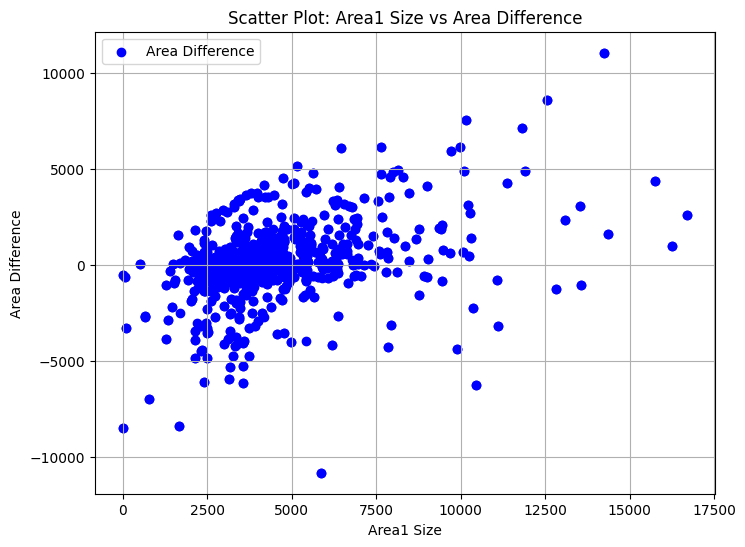

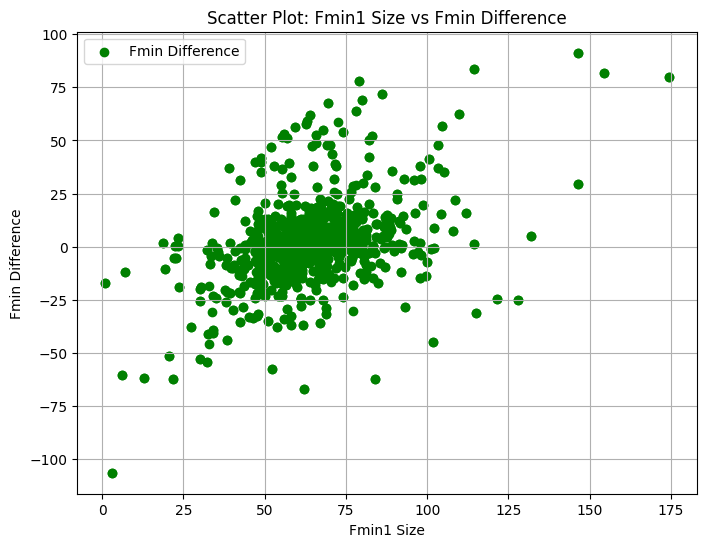

In [11]:
# Scatter plot for area1_size vs area_difference
plt.figure(figsize=(8, 6))
plt.scatter(area1, area_diff, color='blue', label='Area Difference')
plt.xlabel('Area1 Size')
plt.ylabel('Area Difference')
plt.title('Scatter Plot: Area1 Size vs Area Difference')
plt.legend()
plt.grid(True)
plt.show()

# Scatter plot for fmin1_size vs fmin_difference
plt.figure(figsize=(8, 6))
plt.scatter(fmin1, fmin_diff, color='green', label='Fmin Difference')
plt.xlabel('Fmin1 Size')
plt.ylabel('Fmin Difference')
plt.title('Scatter Plot: Fmin1 Size vs Fmin Difference')
plt.legend()
plt.grid(True)
plt.show()

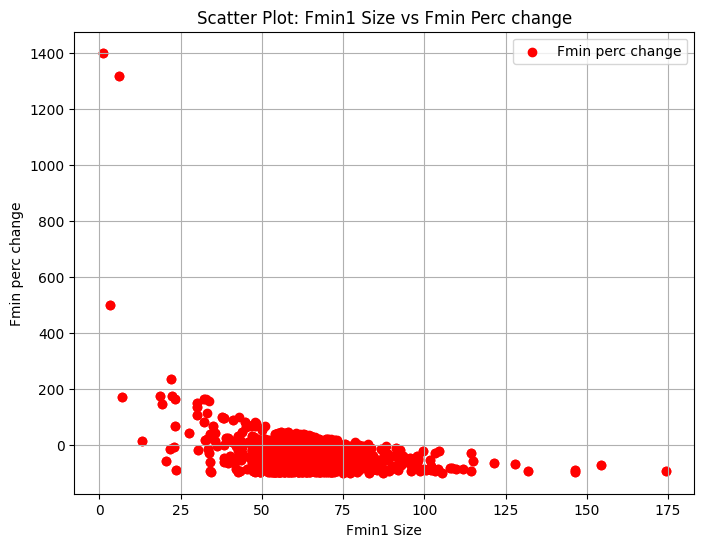

In [16]:
# Scatter plot for fmin1_size vs fmin_difference
plt.figure(figsize=(8, 6))
plt.scatter(fmin1, percentage_change, color='red', label='Fmin perc change')
plt.xlabel('Fmin1 Size')
plt.ylabel('Fmin perc change')
plt.title('Scatter Plot: Fmin1 Size vs Fmin Perc change')
plt.legend()
plt.grid(True)
plt.show()